# 6.1.2 因果滤波与时间延迟

## 学习目标与先修知识

能实现因果滤波（causal filtering），说明移动平均（moving average）的起始窗口如何处理；推导独立噪声平均后的方差（variance），解释平滑与时间延迟（delay）的代价，并辨认使用未来观测（observation）的处理。

先修：[采样间隔与混叠](01-采样间隔与混叠.ipynb)、平均数与[方差、协方差](../../05-随机性与信息/02-期望、方差、协方差与噪声/02-联合变化与协方差.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

在线显示的生理信号通常需要减少快速扰动。但如果一次变化被平滑后晚出现，模型（model）会不会把传感器处理的延迟误认为组织反应慢？同一条缓慢上升曲线，使用过去五点平均和前后五点平均，会给出不同的时间含义。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
values=[0.,1.,2.,3.,4.,5.]
display(Markdown(show_table(['当前序号','当前值 / U','过去至多 5 点的平均 / U'],[(n,values[n],sum(values[max(0,n-4):n+1])/min(n+1,5)) for n in range(len(values))])))

| 当前序号 | 当前值 / U | 过去至多 5 点的平均 / U |
| --- | --- | --- |
| 0 | 0 | 0 |
| 1 | 1 | 0.5 |
| 2 | 2 | 1 |
| 3 | 3 | 1.5 |
| 4 | 4 | 2 |
| 5 | 5 | 3 |

## 模型假设

$x_n$ 是每 $\Delta t=1$ s 到达的一次浓度（concentration）偏差观测，单位 U。在线输出（output）只能使用当前及过去的数据。窗口长度 $W$ 为正整数，表示最多平均多少点，并不是数值求解步长。我们不使用记录开始前的未知数值。

用于说明时间延迟的缓慢趋势、阶跃和快速正弦扰动均是人为设计的确定性信号。后面的噪声方差推导另设 $x_n=s_n+\epsilon_n$，$\epsilon_n$ 独立、零均值且同方差（homoscedasticity） $\sigma^2$；正弦扰动与随机误差分别用于观察波形变化和计算方差。

## 数学解释与推导

记 $m_n=\min(W,n+1)$，因果平均为

$$y_n=\frac{1}{m_n}\sum_{j=0}^{m_n-1}x_{n-j}.$$

开始时只有一两个点，就除以实际点数；若把缺失历史当零却仍除以 $W$，常量序列会在开头被人为压低。窗口满后，每个点权重固定为 $1/W$。

满窗时对斜坡 $s_n=a+bn$，利用 $\sum_{j=0}^{W-1}j=W(W-1)/2$，得到

$$\frac1W\sum_{j=0}^{W-1}(a+b(n-j))=a+b\left(n-\frac{W-1}{2}\right).$$

因此斜坡被推迟 $(W-1)\Delta t/2$；若 $W$ 为偶数，它也可为半个采样（sampling）间隔。这是满窗斜坡的精确结果；任意急剧变化的形状可能同时被展宽，不能只平移一次就解释全部失真。

独立噪声的交叉协方差（covariance）为零，所以平均后的噪声方差为

$$\operatorname{Var}\!\left(\frac1{m_n}\sum_j\epsilon_{n-j}\right)
=\frac{1}{m_n^2}\sum_j\sigma^2=\frac{\sigma^2}{m_n}.$$

若噪声相关，还要加上 $2\sum_{i<j}\operatorname{Cov}(\epsilon_i,\epsilon_j)/m_n^2$。相邻输出复用原始样本，即使原始噪声独立，输出之间也通常相关。噪声变小不等于相对真实趋势的总误差必然变小。

奇数窗 $W=2r+1$ 的居中平均（centered moving average）使用 $x_{n-r},\ldots,x_{n+r}$。它对内区斜坡没有上述时间偏移，却需要未来 $r$ 个值：离线分析可以用；在线显示若使用它，就必须等待 $r\Delta t$ 或承认信息来自未来。

## 核心实现

边界规则写在循环里。因果函数返回同长度列表；居中函数在缺少完整窗口的位置返回 NaN，图中明确留空。

In [3]:
def causal_average(values, window):
    if not isinstance(window, int) or window < 1:
        raise ValueError('window 必须是正整数')
    result=[]
    for n in range(len(values)):
        start=max(0,n-window+1)
        result.append(float(sum(values[start:n+1])/(n-start+1)))
    return result

def centered_average(values, window):
    if window < 1 or window % 2 != 1:
        raise ValueError('居中窗口须为正奇数')
    radius=window//2
    result=np.full(len(values),np.nan)
    for n in range(radius,len(values)-radius):
        result[n]=sum(values[n-radius:n+radius+1])/window
    return result

## 对照实验

左图比较确定性快扰动下的平滑及延迟；右图只比较阶跃，检查提前响应是否来自未来值。

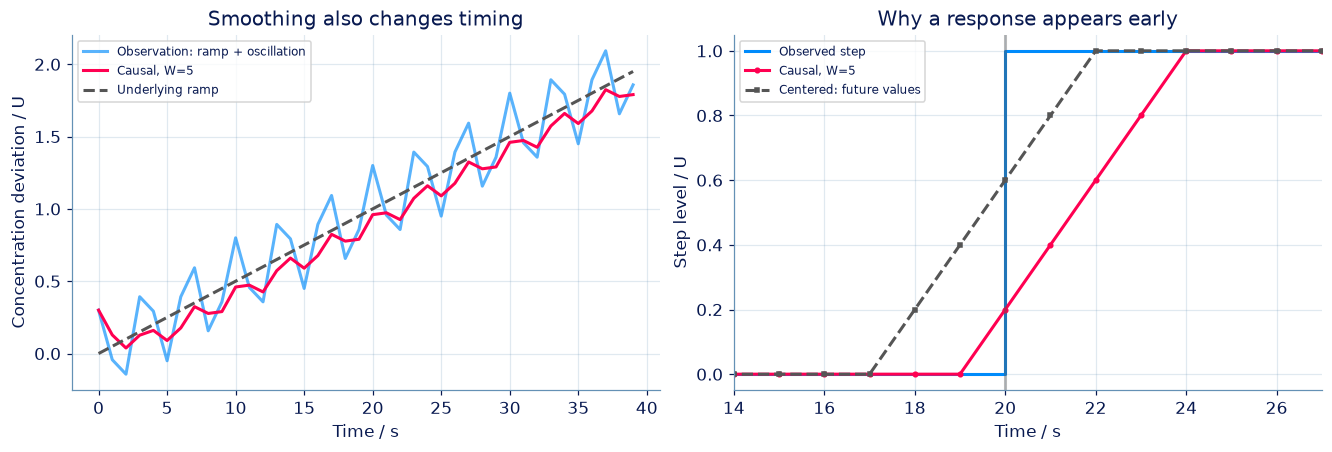

In [4]:
n=np.arange(40); trend=.05*n; observed=trend+.3*np.cos(2*np.pi*.3*n)
step=(n>=20).astype(float)
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(n,observed,color=BLUE,alpha=.65,label='Observation: ramp + oscillation')
axes[0].plot(n,causal_average(observed.tolist(),5),color=PINK,label='Causal, W=5')
axes[0].plot(n,trend,color=GRAY,ls='--',label='Underlying ramp')
axes[0].set(xlabel='Time / s',ylabel='Concentration deviation / U',title='Smoothing also changes timing')
axes[1].step(n,step,where='post',color=BLUE,label='Observed step')
axes[1].plot(n,causal_average(step.tolist(),5),'o-',ms=3,color=PINK,label='Causal, W=5')
axes[1].plot(n,centered_average(step,5),'s--',ms=3,color=GRAY,label='Centered: future values')
axes[1].axvline(20,color=GRAY,alpha=.4)
axes[1].set(xlabel='Time / s',ylabel='Step level / U',xlim=(14,27),title='Why a response appears early')
for ax in axes:ax.legend(fontsize=8)
plt.show()

## 结果解释

因果平均不能在观测阶跃之前响应；居中平均在第 18 点已读到了第 20 点。两条曲线的时间戳若都标为“当前”，就隐含了不同的信息集合。起始归一化保住了常量值，但也使起始阶段的权重随时间改变；不能把整段运算都当作固定卷积核，下一节会区分它们。

### 独立核对

枚举四个独立等概率（probability）的 ±1 扰动组合，直接核对双点均值方差；再用解析斜坡核对延迟，并检查追加未来数据不改变历史因果输出。

In [5]:
np.testing.assert_allclose(causal_average([7.]*8,5),7.)
assert causal_average([],3)==[]
assert causal_average([1.,3.,5.],1)==[1.,3.,5.]
ramp=np.arange(20,dtype=float)
np.testing.assert_allclose(causal_average(ramp.tolist(),5)[4:],ramp[4:]-2)
averages=[(a+b)/2 for a in [-1.,1.] for b in [-1.,1.]]
np.testing.assert_allclose(np.var(averages),.5)
prefix=[1.,4.,-2.,3.]
np.testing.assert_allclose(causal_average(prefix+[100.],3)[:len(prefix)],causal_average(prefix,3))
assert centered_average(step,5)[18]>0 and causal_average(step.tolist(),5)[18]==0
print('常量边界、独立噪声方差、斜坡延迟与因果前缀检查通过。')

常量边界、独立噪声方差、斜坡延迟与因果前缀检查通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/06-01-观测、采样与滤波/explore/)：改变采样或窗口条件，比较图形后返回本节推导。

## 练习与参考资料

习题由统一题库同步。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：只用已经到达的读数

在线传感器每收到一个读数就返回过去 window 个读数的平均。记录开始时只对已经到达的点取平均。

**函数与代码模板**

```python
def solve(
    values: list[float],
    window: int,
) -> list[float]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 按时刻顺序排列的完整读数。 | U |
| `window` | `int` | 最多使用的最近读数个数。 | 点 |

**返回值**

直接返回 smoothed（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `smoothed` | `list[float]` | 与输入（input）等长的因果均值。 | U |

**计算规则**

第 n 项平均 values[max(0,n-window+1):n+1]；分母是该片段实际长度；不补零，不读取未来值。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 0—100 个读数，各项绝对值≤100；1≤window≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 按时刻顺序排列的完整读数。 | [2.0, 4.0, 8.0, 10.0] | U |
| window | 最多使用的最近读数个数。 | 3 | 点 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [2.0, 4.0, 8.0, 10.0]
window = 3

result = solve(values, window)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| smoothed | 与输入（input）等长的因果均值。 | [2.0, 3.0, 4.666666666666667, 7.333333333333333] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.0,
                   3.0,
                   4.666666666666667,
                   7.333333333333333]
```

**样例解释**

结果 [2,3,14/3,22/3] U。第三项开始使用满窗口，第四项只使用 [4,8,10]。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：只用已经到达的读数](http://127.0.0.1:8000/chapters/06-01-%E8%A7%82%E6%B5%8B%E3%80%81%E9%87%87%E6%A0%B7%E4%B8%8E%E6%BB%A4%E6%B3%A2/practice/?question=p06-causal-average)

### 第 2 题 · 单项选择题：居中均值是否适合实时报警

对当前索引 n 使用 (x[n−1]+x[n]+x[n+1])/3。哪项正确？

- **A.** 使用了一个未来读数，实时实现需要等待或改变算法。
- **B.** 公式短，所以不会引入数据泄漏（data leakage）。
- **C.** 与过去三点均值逐时刻完全相同。
- **D.** 不等到下一次读数就能在线得到精确结果。

[作答：居中均值是否适合实时报警](http://127.0.0.1:8000/chapters/06-01-%E8%A7%82%E6%B5%8B%E3%80%81%E9%87%87%E6%A0%B7%E4%B8%8E%E6%BB%A4%E6%B3%A2/practice/?question=p06-centered-lookahead)

### 第 3 题 · 多项选择题：平滑与延迟如何一起解释

等间隔采样（sampling）、固定长度 W 的均值核，在满窗口且低频通带内讨论响应。哪些正确？

- **A.** 该对称因果核在非零通带内有约 (W−1)/2 个采样间隔的延迟（delay）。
- **B.** 相关噪声也一定满足1/W方差（variance）公式。
- **C.** 独立零均值同方差（homoscedasticity）噪声平均后的方差为原来的1/W。
- **D.** 所有信号成分都只变平滑，不改变幅度或相位（phase）。

[作答：平滑与延迟如何一起解释](http://127.0.0.1:8000/chapters/06-01-%E8%A7%82%E6%B5%8B%E3%80%81%E9%87%87%E6%A0%B7%E4%B8%8E%E6%BB%A4%E6%B3%A2/practice/?question=p06-filter-delay)

### 第 4 题 · 多项选择题：前缀平均与固定FIR相同吗

对常数输入（input） [3,3,3]、W=3，比较本节前缀重归一均值与零延拓（zero extension）、始终除以3的有限脉冲响应（finite impulse response，FIR）滤波。哪些正确？

- **A.** 因为稳态相同，所以启动段也可以混用。
- **B.** 前者返回 [3,3,3]。
- **C.** 后者返回前3项 [1,2,3]。
- **D.** 它们启动段不同，边界规则必须声明。

[作答：前缀平均与固定FIR相同吗](http://127.0.0.1:8000/chapters/06-01-%E8%A7%82%E6%B5%8B%E3%80%81%E9%87%87%E6%A0%B7%E4%B8%8E%E6%BB%A4%E6%B3%A2/practice/?question=p06-startup-filter)

**进一步阅读**

[MIT 6.003 第 9 讲：Frequency response](https://ocw.mit.edu/courses/6-003-signals-and-systems-fall-2011/resources/mit6_003f11_lec09/)：滤波如何改变不同频率分量；本节先在时域用平均数推导。